# Import needed modules

In [1]:
#!pip install tensorflow==2.9.1

modules loaded
Found 3373 validated image filenames belonging to 4 classes.
Found 422 validated image filenames belonging to 4 classes.
Found 422 validated image filenames belonging to 4 classes.


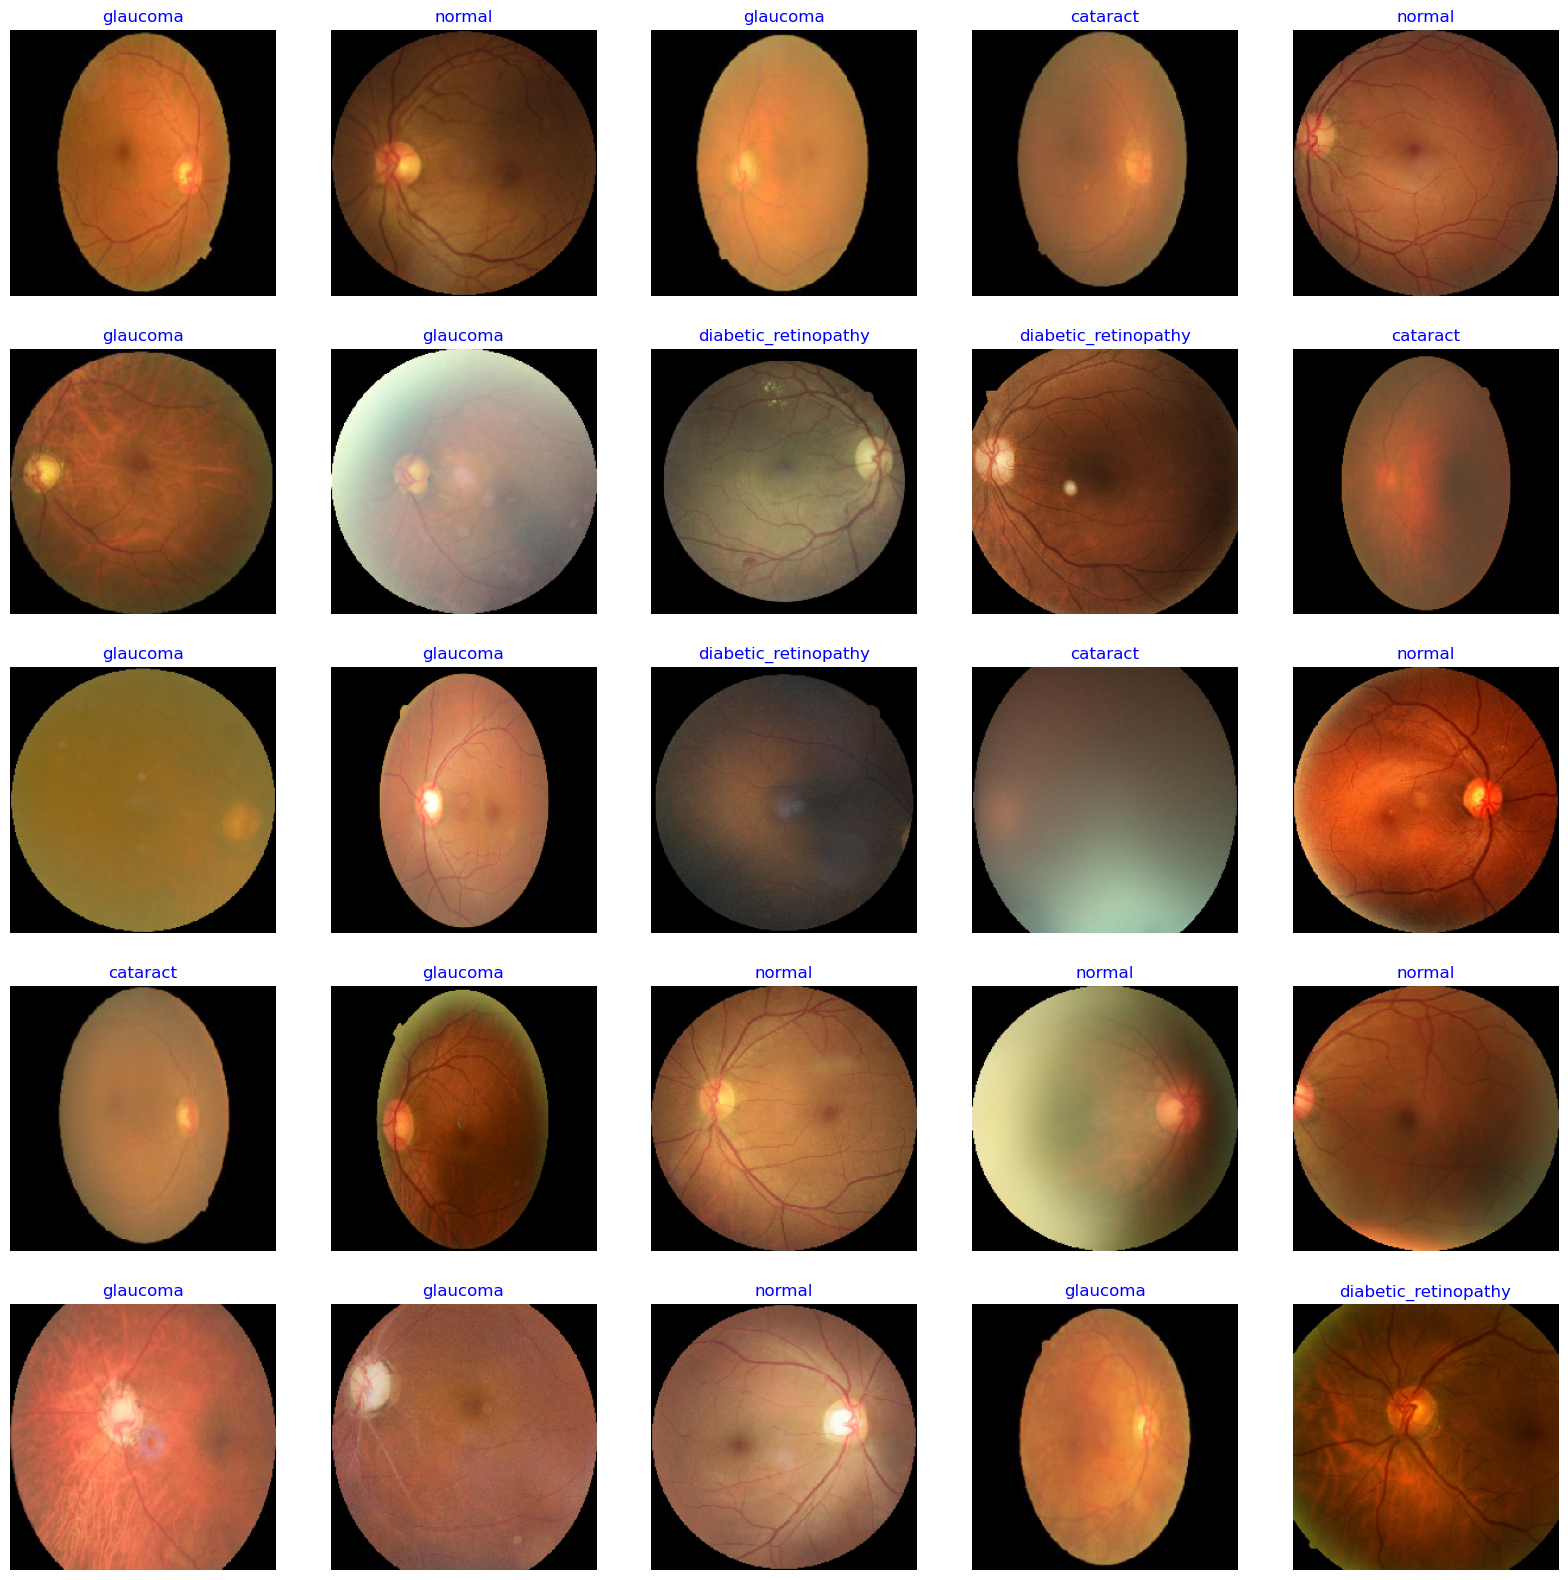

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 224, 224, 32)      896       
                                                                 
 batch_normalization (BatchN  (None, 224, 224, 32)     128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 112, 112, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 112, 112, 64)      18496     
                                                                 
 batch_normalization_1 (Batc  (None, 112, 112, 64)     256       
 hNormalization)                                                 
                                                        

 n


 Epoch     Loss   Accuracy  V_loss    V_acc     LR     Next LR  Monitor  % Improv  Duration
 1 /40     1.225   45.301   1.39361  26.066   0.00100  0.00100  accuracy     0.00    65.27  
 2 /40     1.048   56.923   1.42075  25.118   0.00100  0.00100  accuracy    25.65    31.73  
 3 /40     0.921   61.844   1.77841  30.332   0.00100  0.00100  accuracy     8.65    31.93  
 4 /40     0.875   64.245   2.11717  32.227   0.00100  0.00100  accuracy     3.88    31.21  
 5 /40     0.818   67.003   2.70439  34.123   0.00100  0.00100  accuracy     4.29    31.23  
 6 /40     0.792   68.070   2.69482  31.280   0.00100  0.00100  accuracy     1.59    31.73  
 7 /40     0.767   68.604   3.23860  30.332   0.00100  0.00100  accuracy     0.78    31.48  
 8 /40     0.739   71.213   1.45787  43.602   0.00100  0.00100  accuracy     3.80    31.59  
 9 /40     0.700   72.339   0.80836  65.166   0.00100  0.00100  accuracy     1.58    31.80  
10 /40     0.691   73.080   1.06926  58.531   0.00100  0.00100  accurac

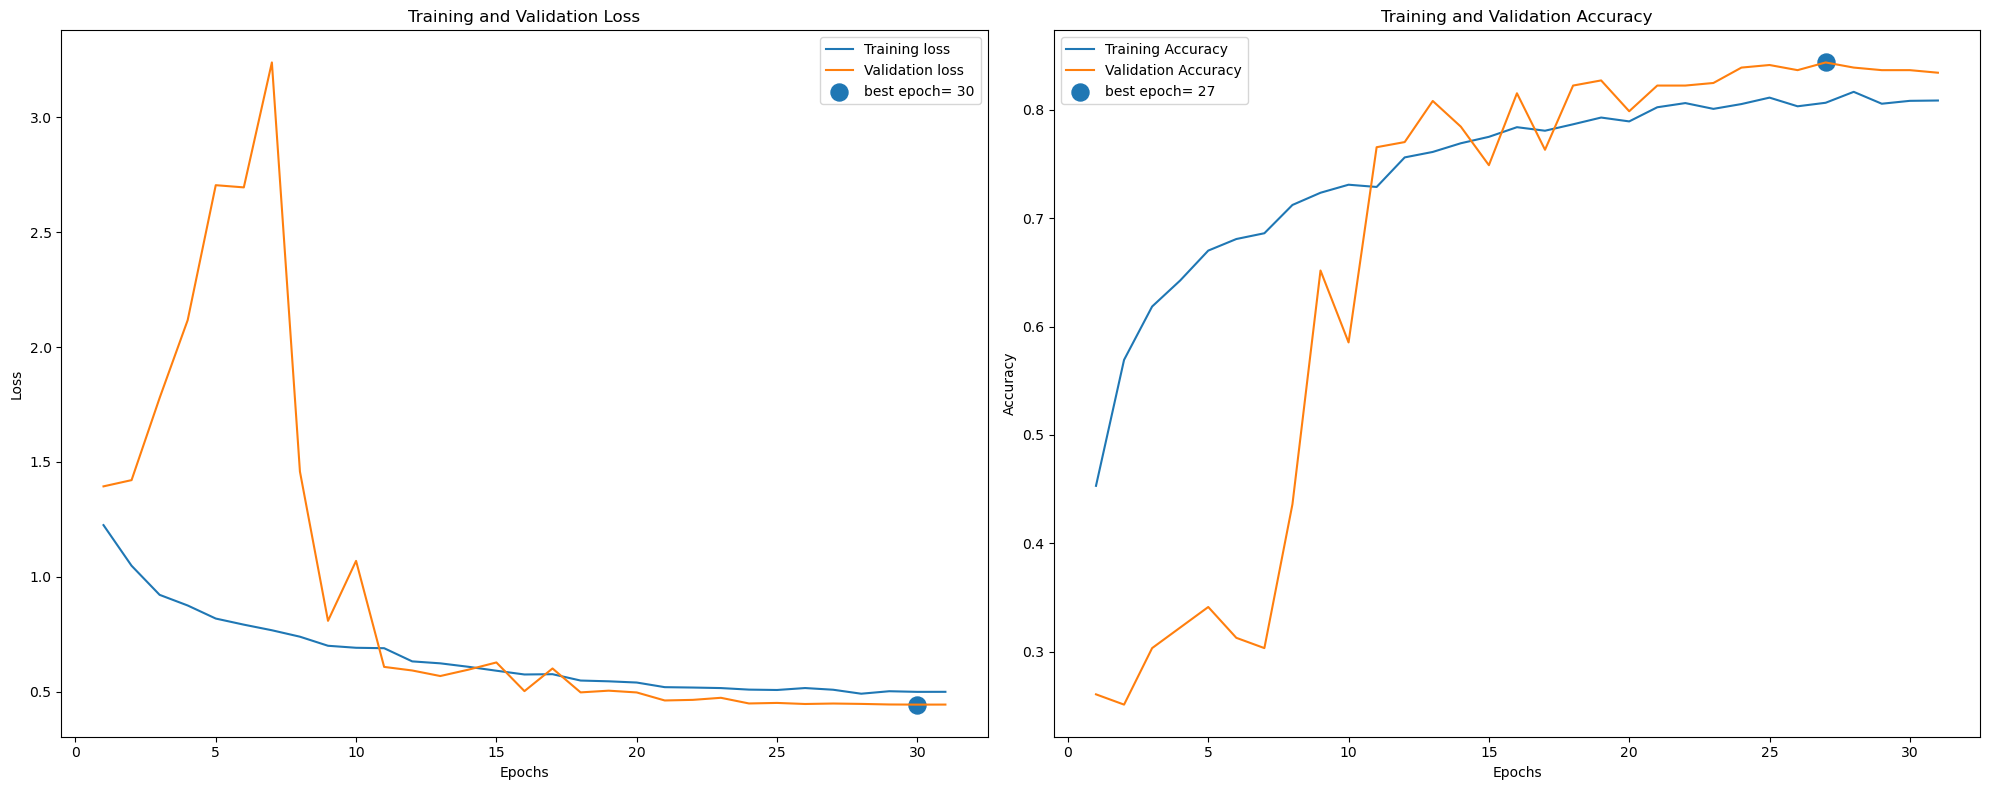

211/211 [==============================] - 7s 34ms/step - loss: 0.4552 - accuracy: 0.8270

Train Loss: 0.4348468482494354  Train Acc: 0.8360509872436523
Valid Loss: 0.44682538509368896  Valid Acc: 0.8388625383377075
Test  Loss: 0.45516735315322876  Test  Acc: 0.8270142078399658
211/211 [==============================] - 4s 19ms/step
Confusion Matrix, Without Normalization
[[ 84   0  13   7]
 [  1 100   2   7]
 [ 14   3  66  18]
 [  4   1   3  99]]


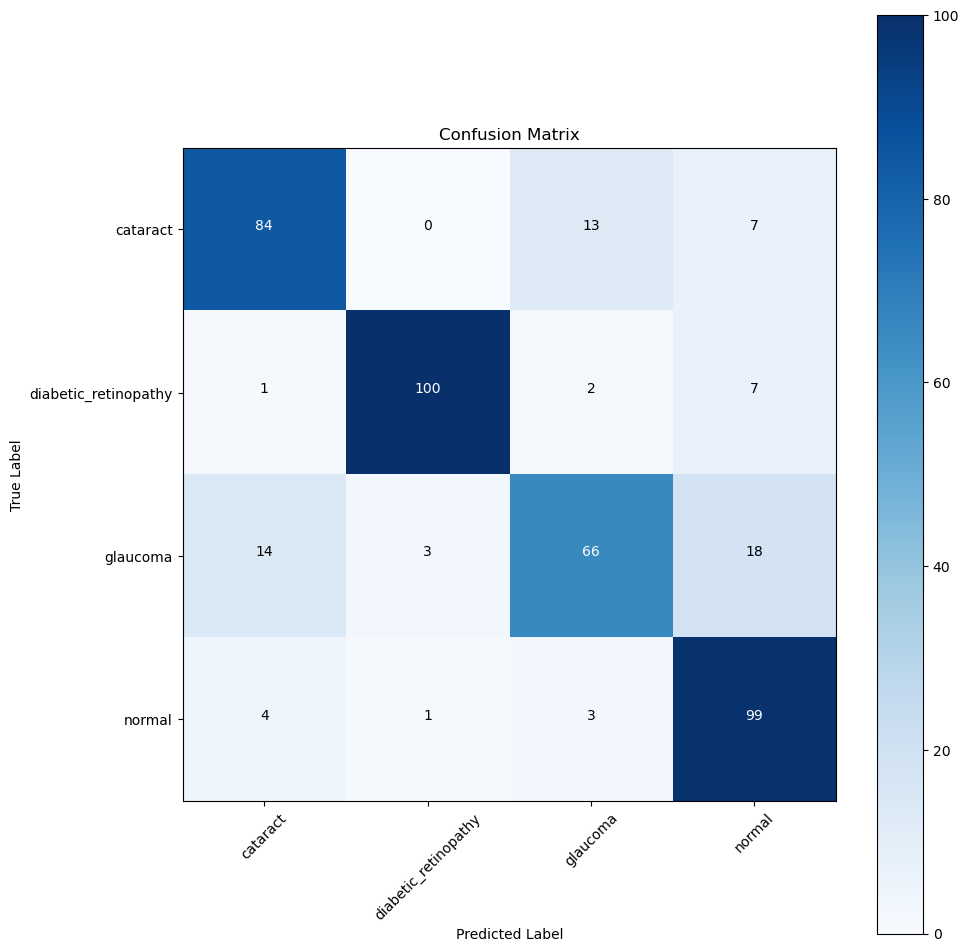

                      precision    recall  f1-score   support

            cataract       0.82      0.81      0.81       104
diabetic_retinopathy       0.96      0.91      0.93       110
            glaucoma       0.79      0.65      0.71       101
              normal       0.76      0.93      0.83       107

            accuracy                           0.83       422
           macro avg       0.83      0.82      0.82       422
        weighted avg       0.83      0.83      0.83       422



In [2]:


# ---------------------------
# 0) System / general libs
# ---------------------------
import os, time, shutil, pathlib, itertools, warnings
warnings.filterwarnings("ignore")

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# ---------------------------
# 1) Deep Learning libs
# ---------------------------
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras import regularizers

print("modules loaded")

# ---------------------------
# 2) Optional: install LIME/SHAP if missing (Kaggle safe)
# ---------------------------
def _pip_install(pkg):
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

try:
    import lime
    from lime import lime_image
except Exception:
    print("Installing LIME...")
    _pip_install("lime")
    from lime import lime_image

try:
    import shap
except Exception:
    print("Installing SHAP...")
    _pip_install("shap")
    import shap

# For LIME visualization
from skimage.segmentation import mark_boundaries

# ============================================================
# 3) Data utilities (paths -> dataframe -> split)
# ============================================================
def define_paths(data_dir):
    filepaths, labels = [], []
    folds = os.listdir(data_dir)
    for fold in folds:
        foldpath = os.path.join(data_dir, fold)
        if not os.path.isdir(foldpath):
            continue
        for file in os.listdir(foldpath):
            fpath = os.path.join(foldpath, file)
            filepaths.append(fpath)
            labels.append(fold)
    return filepaths, labels

def define_df(files, classes):
    return pd.concat([pd.Series(files, name="filepaths"),
                      pd.Series(classes, name="labels")], axis=1)

def split_data(data_dir, seed=123):
    files, classes = define_paths(data_dir)
    df = define_df(files, classes)
    strat = df["labels"]
    train_df, dummy_df = train_test_split(
        df, train_size=0.8, shuffle=True, random_state=seed, stratify=strat
    )
    strat = dummy_df["labels"]
    valid_df, test_df = train_test_split(
        dummy_df, train_size=0.5, shuffle=True, random_state=seed, stratify=strat
    )
    return train_df, valid_df, test_df

def create_gens(train_df, valid_df, test_df, batch_size):
    """
    Uses rescale=1/255 so inputs match manuscript normalization ([0,1]).
    """
    img_size = (224, 224)
    color = "rgb"

    ts_length = len(test_df)
    test_batch_size = max(sorted([
        ts_length // n for n in range(1, ts_length + 1)
        if ts_length % n == 0 and ts_length / n <= 80
    ]))
    test_steps = ts_length // test_batch_size

    # Consistent normalization
    tr_gen = ImageDataGenerator(rescale=1.0/255.0, horizontal_flip=True)
    ts_gen = ImageDataGenerator(rescale=1.0/255.0)

    train_gen = tr_gen.flow_from_dataframe(
        train_df, x_col="filepaths", y_col="labels",
        target_size=img_size, class_mode="categorical",
        color_mode=color, shuffle=True, batch_size=batch_size
    )
    valid_gen = ts_gen.flow_from_dataframe(
        valid_df, x_col="filepaths", y_col="labels",
        target_size=img_size, class_mode="categorical",
        color_mode=color, shuffle=True, batch_size=batch_size
    )
    test_gen = ts_gen.flow_from_dataframe(
        test_df, x_col="filepaths", y_col="labels",
        target_size=img_size, class_mode="categorical",
        color_mode=color, shuffle=False, batch_size=test_batch_size
    )

    return train_gen, valid_gen, test_gen, test_steps

def show_images(gen, max_show=25):
    g_dict = gen.class_indices
    classes = list(g_dict.keys())
    images, labels = next(gen)

    sample = min(len(labels), max_show)
    plt.figure(figsize=(20, 20))
    for i in range(sample):
        plt.subplot(5, 5, i + 1)
        plt.imshow(images[i])  # already [0,1] due to rescale
        index = np.argmax(labels[i])
        plt.title(classes[index], color="blue", fontsize=12)
        plt.axis("off")
    plt.show()

# ============================================================
# 4) Training callback (fixed indentation bug)
# ============================================================
class MyCallback(keras.callbacks.Callback):
    def __init__(self, model, patience, stop_patience, threshold, factor, batches, epochs, ask_epoch):
        super().__init__()
        self.model = model
        self.patience = patience
        self.stop_patience = stop_patience
        self.threshold = threshold
        self.factor = factor
        self.batches = batches
        self.epochs = epochs
        self.ask_epoch = ask_epoch
        self.ask_epoch_initial = ask_epoch

        self.count = 0
        self.stop_count = 0
        self.best_epoch = 1
        self.initial_lr = float(tf.keras.backend.get_value(model.optimizer.lr))
        self.highest_tracc = 0.0
        self.lowest_vloss = np.inf
        self.best_weights = self.model.get_weights()

    def on_train_begin(self, logs=None):
        msg = "Do you want model asks you to halt the training [y/n] ?"
        print(msg)
        ans = input("")
        self.ask_permission = 1 if ans in ["Y", "y"] else 0

        header = "{0:^8s}{1:^10s}{2:^9s}{3:^9s}{4:^9s}{5:^9s}{6:^9s}{7:^10s}{8:10s}{9:^8s}".format(
            "Epoch", "Loss", "Accuracy", "V_loss", "V_acc", "LR", "Next LR", "Monitor", "% Improv", "Duration"
        )
        print(header)
        self.start_time = time.time()

    def on_train_end(self, logs=None):
        stop_time = time.time()
        tr_duration = stop_time - self.start_time
        hours = tr_duration // 3600
        minutes = (tr_duration - (hours * 3600)) // 60
        seconds = tr_duration - ((hours * 3600) + (minutes * 60))
        print(f"training elapsed time was {int(hours)} hours, {minutes:4.1f} minutes, {seconds:4.2f} seconds")
        self.model.set_weights(self.best_weights)

    def on_train_batch_end(self, batch, logs=None):
        acc = logs.get("accuracy", 0) * 100
        loss = logs.get("loss", 0)
        msg = "{0:20s}processing batch {1:} of {2:5s}-   accuracy=  {3:5.3f}   -   loss: {4:8.5f}".format(
            " ", str(batch), str(self.batches), acc, loss
        )
        print(msg, "\r", end="")

    def on_epoch_begin(self, epoch, logs=None):
        self.ep_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        ep_end = time.time()
        duration = ep_end - self.ep_start

        lr = float(tf.keras.backend.get_value(self.model.optimizer.lr))
        current_lr = lr

        acc = logs.get("accuracy", 0)
        v_acc = logs.get("val_accuracy", 0)
        loss = logs.get("loss", 0)
        v_loss = logs.get("val_loss", np.inf)

        if acc < self.threshold:
            monitor = "accuracy"
            pimprov = 0.0 if self.highest_tracc == 0 else (acc - self.highest_tracc) * 100 / self.highest_tracc

            if acc > self.highest_tracc:
                self.highest_tracc = acc
                self.best_weights = self.model.get_weights()
                self.count = 0
                self.stop_count = 0
                if v_loss < self.lowest_vloss:
                    self.lowest_vloss = v_loss
                self.best_epoch = epoch + 1
            else:
                if self.count >= self.patience - 1:
                    lr = lr * self.factor
                    tf.keras.backend.set_value(self.model.optimizer.lr, lr)
                    self.count = 0
                    self.stop_count += 1
                    if v_loss < self.lowest_vloss:
                        self.lowest_vloss = v_loss
                else:
                    self.count += 1
        else:
            monitor = "val_loss"
            pimprov = 0.0 if self.lowest_vloss == np.inf else (self.lowest_vloss - v_loss) * 100 / self.lowest_vloss

            if v_loss < self.lowest_vloss:
                self.lowest_vloss = v_loss
                self.best_weights = self.model.get_weights()  # fixed indentation
                self.count = 0
                self.stop_count = 0
                self.best_epoch = epoch + 1
            else:
                if self.count >= self.patience - 1:
                    lr = lr * self.factor
                    self.stop_count += 1
                    self.count = 0
                    tf.keras.backend.set_value(self.model.optimizer.lr, lr)
                else:
                    self.count += 1

                if acc > self.highest_tracc:
                    self.highest_tracc = acc

        msg = f"{str(epoch + 1):^3s}/{str(self.epochs):4s} {loss:^9.3f}{acc * 100:^9.3f}{v_loss:^9.5f}{v_acc * 100:^9.3f}{current_lr:^9.5f}{lr:^9.5f}{monitor:^11s}{pimprov:^10.2f}{duration:^8.2f}"
        print(msg)

        if self.stop_count > self.stop_patience - 1:
            print(f" training halted at epoch {epoch + 1} after {self.stop_patience} LR adjustments with no improvement")
            self.model.stop_training = True
        else:
            if self.ask_epoch is not None and self.ask_permission != 0:
                if epoch + 1 >= self.ask_epoch:
                    print("enter H to halt training or an integer for number of epochs to run then ask again")
                    ans = input("")
                    if ans.lower() == "h":
                        print(f"training halted at epoch {epoch + 1} due to user input")
                        self.model.stop_training = True
                    else:
                        try:
                            ans = int(ans)
                            self.ask_epoch += ans
                            print(f" training will continue until epoch {str(self.ask_epoch)}")
                            header = "{0:^8s}{1:^10s}{2:^9s}{3:^9s}{4:^9s}{5:^9s}{6:^9s}{7:^10s}{8:10s}{9:^8s}".format(
                                "Epoch", "Loss", "Accuracy", "V_loss", "V_acc", "LR", "Next LR", "Monitor", "% Improv", "Duration"
                            )
                            print(header)
                        except Exception:
                            print("Invalid input")

def plot_training(hist):
    tr_acc = hist.history["accuracy"]
    tr_loss = hist.history["loss"]
    val_acc = hist.history["val_accuracy"]
    val_loss = hist.history["val_loss"]

    index_loss = int(np.argmin(val_loss))
    index_acc = int(np.argmax(val_acc))
    Epochs = [i + 1 for i in range(len(tr_acc))]

    plt.figure(figsize=(20, 8))

    plt.subplot(1, 2, 1)
    plt.plot(Epochs, tr_loss, label="Training loss")
    plt.plot(Epochs, val_loss, label="Validation loss")
    plt.scatter(index_loss + 1, val_loss[index_loss], s=150, label=f"best epoch= {index_loss + 1}")
    plt.title("Training and Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(Epochs, tr_acc, label="Training Accuracy")
    plt.plot(Epochs, val_acc, label="Validation Accuracy")
    plt.scatter(index_acc + 1, val_acc[index_acc], s=150, label=f"best epoch= {index_acc + 1}")
    plt.title("Training and Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(cm, classes, normalize=False, title="Confusion Matrix", cmap=plt.cm.Blues):
    plt.figure(figsize=(10, 10))
    plt.imshow(cm, interpolation="nearest", cmap=cmap)
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized Confusion Matrix")
    else:
        print("Confusion Matrix, Without Normalization")

    print(cm)

    thresh = cm.max() / 2.0
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j], horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()

# ============================================================
# 5) Load data
# ============================================================
data_dir = "/kaggle/input/eye-diseases-classification/dataset"

train_df, valid_df, test_df = split_data(data_dir)
batch_size = 40
train_gen, valid_gen, test_gen, test_steps = create_gens(train_df, valid_df, test_df, batch_size)

show_images(train_gen)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

def build_scratch_cnn(input_shape=(224,224,3), num_classes=4):
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        GlobalAveragePooling2D(),

        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

scratch_model = build_scratch_cnn()
scratch_model.summary()


scratch_model.compile(Adamax(learning_rate=0.001), loss="categorical_crossentropy", metrics=["accuracy"])


# ============================================================
# 7) Train
# ============================================================
epochs = 40
patience = 1
stop_patience = 3
threshold = 0.9
factor = 0.5
ask_epoch = 5
batches = int(np.ceil(len(train_gen.labels) / batch_size))

callbacks = [MyCallback(model= scratch_model, patience=patience, stop_patience=stop_patience,
                        threshold=threshold, factor=factor, batches=batches,
                        epochs=epochs, ask_epoch=ask_epoch)]

history = scratch_model.fit(
    x=train_gen,
    epochs=epochs,
    verbose=0,
    callbacks=callbacks,
    validation_data=valid_gen,
    shuffle=False
)

plot_training(history)

# ============================================================
# 8) Evaluate + Reports
# ============================================================
train_score = scratch_model.evaluate(train_gen, steps=test_steps, verbose=1)
valid_score = scratch_model.evaluate(valid_gen, steps=test_steps, verbose=1)
test_score  = scratch_model.evaluate(test_gen,  steps=test_steps, verbose=1)

print("\nTrain Loss:", train_score[0], " Train Acc:", train_score[1])
print("Valid Loss:", valid_score[0], " Valid Acc:", valid_score[1])
print("Test  Loss:", test_score[0],  " Test  Acc:", test_score[1])

preds = scratch_model.predict(test_gen, verbose=1)
y_pred = np.argmax(preds, axis=1)

g_dict = test_gen.class_indices
classes = list(g_dict.keys())

cm = confusion_matrix(test_gen.classes, y_pred)
plot_confusion_matrix(cm=cm, classes=classes, title="Confusion Matrix")

print(classification_report(test_gen.classes, y_pred, target_names=classes))


